<a href="https://colab.research.google.com/github/KazGet/Pet-and-educational-projects/blob/main/Codenrock.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
!pip install catboost
import numpy as np
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.5 MB/s eta 0:00:00


In [ ]:
df = pd.read_csv('/content/train.csv')
df = df.drop(['building_age_years'], axis=1)

In [ ]:
df.head()

,apartment_id,wing,entrance,floor,apartment_area_m2,ceiling_height_m,window_quality,heating_type,corner_apartment,room_temp_c,...,stand_type,cut_days_before_jan1,potted_tree,waterings_per_week,mist_spray,tinsel_level,ornaments_weight_kg,led_garland,garland_hours_per_day,survived_to_18jan
0,apt_train_000001,east,6,16,58.7,2.73,new,central,1,21.8,...,bucket,10,0,1.0,1,high,4.53,0,11.3,1
1,apt_train_000002,west,9,20,61.9,2.72,normal,electric_heater,1,21.9,...,bucket,12,0,1.0,1,low,NaN,0,2.9,0
2,apt_train_000003,north,2,9,48.0,2.48,normal,central,0,20.0,...,simple_stand,0,0,2.0,0,medium,3.17,1,15.2,0
3,apt_train_000004,west,11,14,32.1,2.54,normal,central,1,25.5,...,water_reservoir,22,0,6.0,1,medium,2.90,0,4.6,0
4,apt_train_000005,south,3,20,57.9,2.73,old,electric_heater,1,20.8,...,water_reservoir,2,0,4.0,1,medium,2.38,1,0.0,1


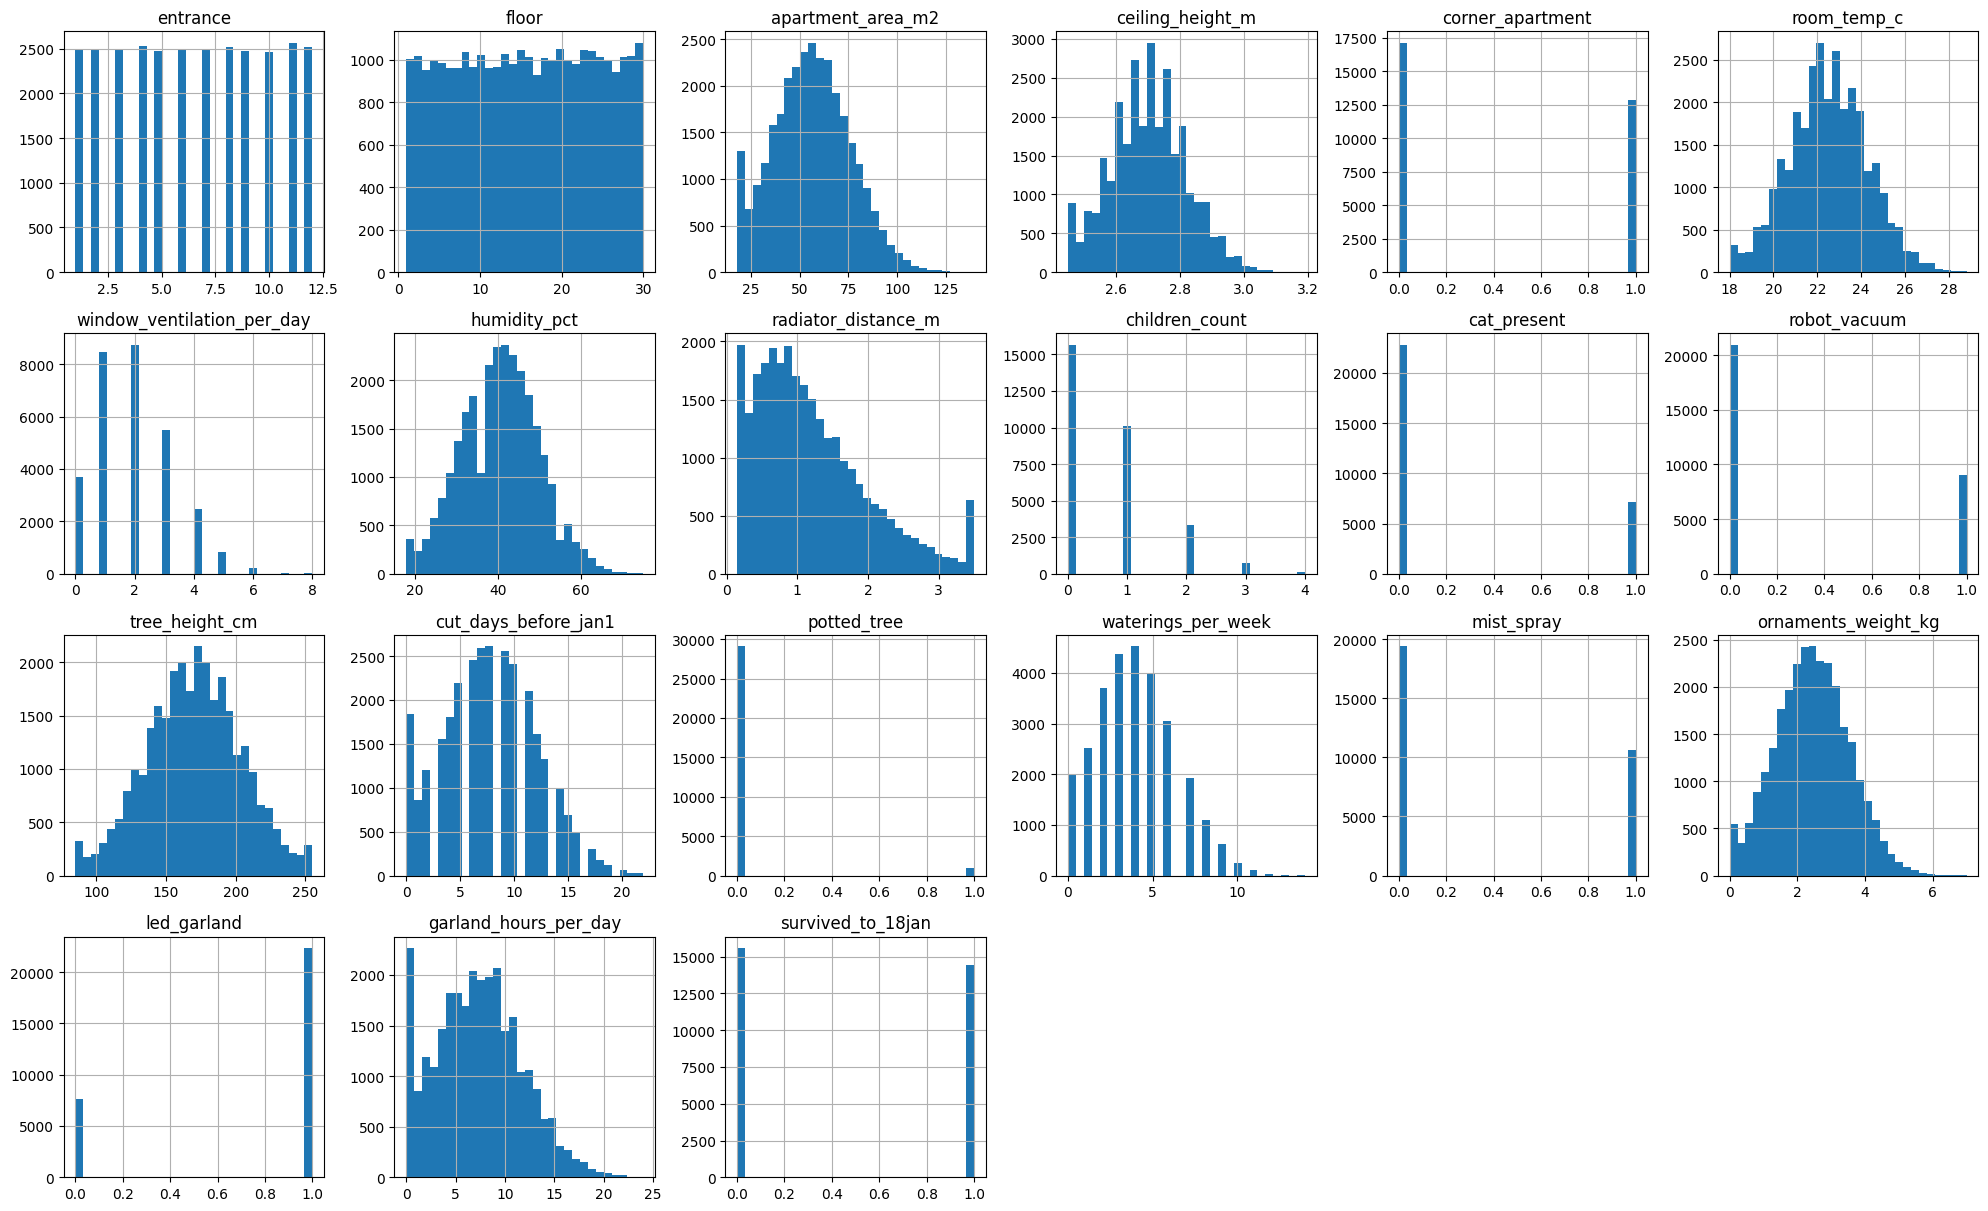

In [ ]:
# Только числовые столбцы
numeric_cols = df.select_dtypes(include=['number']).columns
df[numeric_cols].hist(figsize=(20, 15), bins=30, layout=(5, 6))  # 5 строк, 6 столбцов
plt.tight_layout()
plt.show()

In [ ]:
clip_features = [
    "ornaments_weight_kg",
    "garland_hours_per_day",
    "waterings_per_week",
    'window_ventilation_per_day',
    'tree_height_cm',
    'room_temp_c'
]
def clip_by_quantile(train, cols, q=0.99):
    thresholds = {}
    for col in cols:
        thr = train[col].quantile(q)
        thresholds[col] = thr
        train[col] = train[col].clip(upper=thr)
    return train, thresholds

train_df, clip_vals = clip_by_quantile(
    df,
    clip_features
)


In [ ]:
# train_df['diff_cat_vacuum'] = train_df['cat_present'] + train_df['robot_vacuum']

# train_df = df.copy()
mean_survival = train_df.groupby('stand_type')['survived_to_18jan'].mean()
train_df['stand_type_te'] = train_df['stand_type'].map(mean_survival)

type_of_tree = train_df.groupby('tree_species')['survived_to_18jan'].mean()
tree_form_te = train_df.groupby('tree_form')['survived_to_18jan'].mean()

train_df['form_plus_species'] = train_df['tree_species'].map(type_of_tree)*train_df['tree_form'].map(tree_form_te)

train_df['dryness_index'] = train_df['room_temp_c']/(train_df['humidity_pct']+1)

train_df['incandescent_heat'] = train_df['garland_hours_per_day'] * (1 - train_df['led_garland'])

train_df['radiator_heat_stress'] = train_df['room_temp_c'] / (train_df['radiator_distance_m'] + 0.1)

train_df['chaos_factor'] = train_df['children_count'] + train_df['cat_present'] + train_df['ornaments_weight_kg']

window_map = {'old': 3, 'normal': 2, 'new': 1} # Старые окна + проветривание = сквозняк
train_df['draft_score'] = train_df['window_ventilation_per_day'] * train_df['window_quality'].map(window_map)

train_df['water_per_cm'] = train_df['waterings_per_week'] / (train_df['tree_height_cm'] + 1)

train_df['real_tree_age'] = (train_df['cut_days_before_jan1'] + 18) * (1 - train_df['potted_tree'])

train_df['incandescent_heat'] = train_df['garland_hours_per_day'] * (1 - train_df['led_garland'])

def calculate_risk_score(row):
    score = 0
    if row['cat_present'] == 1: score += 2
    if row['children_count'] > 0: score += 1

    if row['radiator_distance_m'] < 0.5: score += 2
    if row['room_temp_c'] > 24: score += 1
    if row['humidity_pct'] < 40: score += 2
    if row['window_ventilation_per_day'] > 4: score+=2

    if row['waterings_per_week'] < 1: score += 3
    if row['stand_type'] == 'simple_stand': score += 2

    return score

train_df['total_risk_score'] = train_df.apply(calculate_risk_score, axis=1)


def create_group_stats(df):
    df = df.copy()
    wing_temp_mean = df.groupby('wing')['room_temp_c'].transform('mean')
    df['temp_diff_wing'] = df['room_temp_c'] - wing_temp_mean

    entrance_hum_mean = df.groupby('entrance')['humidity_pct'].transform('mean')
    df['humidity_diff_entrance'] = df['humidity_pct'] - entrance_hum_mean


    species_water_mean = df.groupby('tree_species')['waterings_per_week'].transform('mean')
    df['watering_diff_species'] = df['waterings_per_week'] - species_water_mean


    df['floor_group'] = (df['floor'] // 5).astype(str)
    floor_temp_mean = df.groupby('floor_group')['room_temp_c'].transform('mean')
    df['temp_diff_floor'] = df['room_temp_c'] - floor_temp_mean

    df.drop(columns=['floor_group'], inplace=True)

    return df

train_df = create_group_stats(train_df)

train_df['cat_interaction'] = train_df['cat_present'] * train_df['ornaments_weight_kg'] * (1 - train_df['potted_tree'])
train_df['garland_dryness_hit'] = train_df['incandescent_heat'] * train_df['dryness_index']
train_df['freshness_preservation'] = train_df['waterings_per_week'] / (train_df['cut_days_before_jan1'] + 1)

stand_map = {
    'simple_stand': 1,
    'unknown': 1.5,
    'bucket': 2,
    'water_reservoir': 3
}
train_df['stand_power'] = train_df['stand_type'].map(stand_map)
train_df['hydro_efficiency'] = train_df['stand_power'] * train_df['waterings_per_week']
def create_thermal_gradient_features(df):
    df = df.copy()
    wing_heat_map = {'north': 1, 'east': 2, 'west': 2, 'south': 3}
    df['wing_heat_index'] = df['wing'].map(wing_heat_map)

    def get_corner_correction(row):
        if row['corner_apartment'] == 0:
            return 0
        if row['wing'] in ['south', 'west']:
            return -0.5

        else:
            return 0.5

    df['corner_heat_correction'] = df.apply(get_corner_correction, axis=1)
    df['vertical_heat_factor'] = df['floor'] * 0.05

    df['building_heat_load'] = (
        df['wing_heat_index'] +
        df['vertical_heat_factor'] +
        df['corner_heat_correction']
    )

    df['heat_conflict'] = df['room_temp_c'] / (df['building_heat_load'] + 1)

    return df

train_df = create_thermal_gradient_features(train_df)

In [ ]:
pd.pivot_table(
    train_df,
    values = 'survived_to_18jan',
    index = 'cat_present',
    columns = 'robot_vacuum',
    aggfunc = 'mean'
)

robot_vacuum,0,1
cat_present,,
0,0.489879,0.484487
1,0.455709,0.457051


In [ ]:
pd.pivot_table(
    train_df,
    values='survived_to_18jan',
    index=pd.qcut(train_df['ornaments_weight_kg'], 5),
    columns=['cat_present'],
    aggfunc='mean'
)


/tmp/ipython-input-67259008.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pd.pivot_table(


cat_present,0,1
ornaments_weight_kg,,
"(-0.001, 1.53]",0.493038,0.479333
"(1.53, 2.16]",0.501376,0.476510
"(2.16, 2.71]",0.493656,0.437042
"(2.71, 3.35]",0.497352,0.453343
"(3.35, 7.0]",0.452729,0.435953


In [ ]:
train_df.groupby('')['survived_to_18jan'].mean()

/tmp/ipython-input-2015642748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  train_df.groupby(pd.qcut(train_df['ornaments_weight_kg'], 5))['survived_to_18jan'].mean()


,survived_to_18jan
ornaments_weight_kg,
"(-0.001, 1.53]",0.489757
"(1.53, 2.16]",0.495527
"(2.16, 2.71]",0.479900
"(2.71, 3.35]",0.486851
"(3.35, 7.0]",0.448671


In [ ]:
bins = [85, 110, 145, 175, 205, 225, 255]
labels = ['85-110', '111–145', '146–175', '176–205', '206-225', '226-255']

train_df['cut_bin'] = pd.cut(
    train_df['tree_height_cm'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

pivot = train_df.pivot_table(
    values='survived_to_18jan',
    index=pd.qcur(['tree_height_cm'], 6),
    columns='potted_tree',
    aggfunc='mean'
)

pivot

/tmp/ipython-input-2538653714.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = train_df.pivot_table(


potted_tree,0,1
cut_bin,,
85-110,0.467249,0.641509
111–145,0.473474,0.670732
146–175,0.477668,0.681481
176–205,0.475921,0.636364
206-225,0.472817,0.617284
226-255,0.467840,0.743590


0:	test: 0.6256853	best: 0.6256853 (0)	total: 69.7ms	remaining: 1m 44s
100:	test: 0.6690018	best: 0.6690294 (99)	total: 7.41s	remaining: 1m 42s
200:	test: 0.6730663	best: 0.6730663 (200)	total: 10.3s	remaining: 1m 6s
300:	test: 0.6743763	best: 0.6743865 (299)	total: 12.5s	remaining: 50s
400:	test: 0.6749084	best: 0.6750830 (386)	total: 15.5s	remaining: 42.4s
500:	test: 0.6747041	best: 0.6750896 (411)	total: 18.1s	remaining: 36.2s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.6750895561
bestIteration = 411

Shrink model to first 412 iterations.
0:	test: 0.6282023	best: 0.6282023 (0)	total: 27.7ms	remaining: 41.6s
100:	test: 0.6709422	best: 0.6709422 (100)	total: 2.38s	remaining: 33s
200:	test: 0.6744292	best: 0.6744292 (200)	total: 4.68s	remaining: 30.3s
300:	test: 0.6752943	best: 0.6752943 (300)	total: 7.58s	remaining: 30.2s
400:	test: 0.6758488	best: 0.6762964 (375)	total: 9.95s	remaining: 27.3s
500:	test: 0.6758957	best: 0.6762964 (375)	total: 12.6s	remaining: 

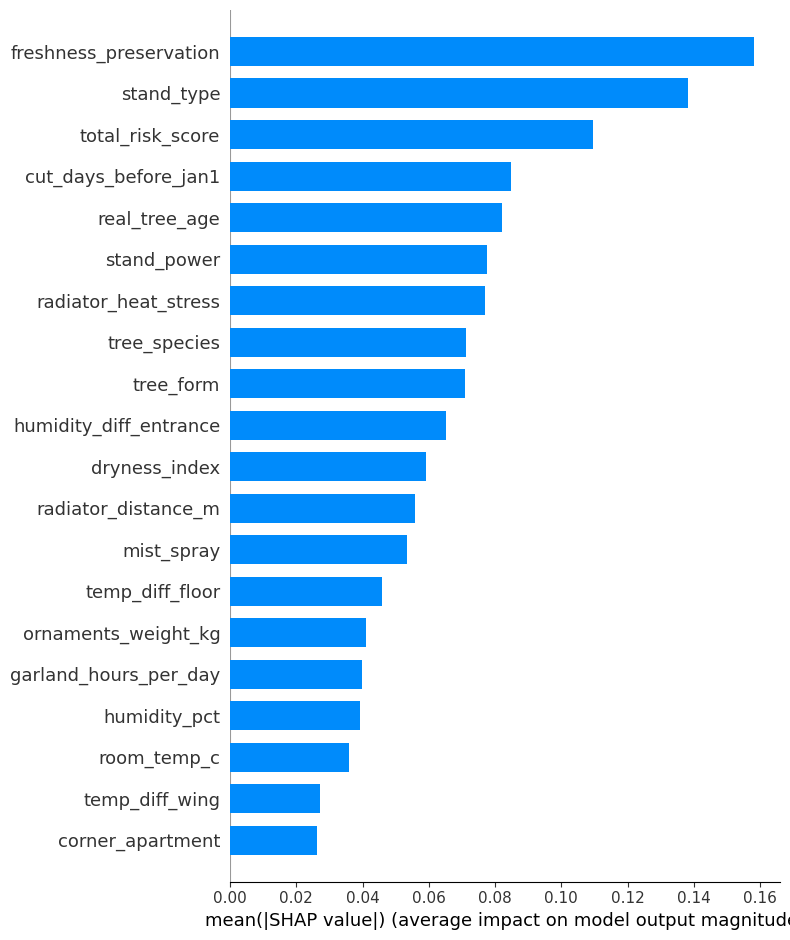

In [ ]:
# @title Обучение
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import shap
import matplotlib.pyplot as plt

target = "survived_to_18jan"

cols_to_take = ['draft_score', 'incandescent_heat',
       'ceiling_height_m', 'temp_diff_wing', 'corner_apartment',
       'heat_conflict', 'ornaments_weight_kg', 'room_temp_c',
       'stand_power', 'temp_diff_floor', 'window_ventilation_per_day',
       'humidity_pct', 'garland_hours_per_day', 'mist_spray',
       'radiator_distance_m', 'stand_type', 'dryness_index',
       'humidity_diff_entrance', 'cut_days_before_jan1',
       'radiator_heat_stress', 'tree_species', 'real_tree_age',
       'tree_form', 'total_risk_score', 'freshness_preservation']

categorical_features = [
    # "wing",
    # "window_quality",
    # "heating_type",
    "tree_species",
    "tree_form", "stand_type",
    # "tinsel_level"
]

shap_values_all = []
X_valid_all = []

drop_cols = [target, "apartment_id", "stand_type_te", "form_plus_species"]

features = [c for c in cols_to_take if c not in drop_cols]

best_params = {'learning_rate': 0.029684085202502875, 'depth': 6, 'l2_leaf_reg': 4.585362521164003, 'random_strength': 2.922016389503037, 'bagging_temperature': 0.4880814017887846}

best_params.update({
    'iterations': 1500,
    'eval_metric': 'AUC',
    'random_seed': 42,
    'early_stopping_rounds': 150,
    'verbose': 100
})

n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

cat_oof_preds = np.zeros(len(train_df))
feature_importances = pd.DataFrame(index=features)

for fold, (train_idx, valid_idx) in enumerate(skf.split(train_df, train_df[target])):
    X_train, X_valid = train_df.iloc[train_idx][features], train_df.iloc[valid_idx][features]
    y_train, y_valid = train_df.iloc[train_idx][target], train_df.iloc[valid_idx][target]

    model = CatBoostClassifier(**best_params)

    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        cat_features=categorical_features,
        use_best_model=True
    )

    cat_oof_preds[valid_idx] = model.predict_proba(X_valid)[:, 1]

    # --- SHAP ---
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_valid)

    shap_values_all.append(shap_vals)
    X_valid_all.append(X_valid)
    feature_importances[f"fold_{fold+1}"] = model.get_feature_importance(
    Pool(X_valid, y_valid, cat_features=categorical_features),
    type="FeatureImportance")

shap_values_all = np.vstack(shap_values_all)
X_valid_all = pd.concat(X_valid_all, axis=0)

auc_score = roc_auc_score(train_df[target], cat_oof_preds)
print(f"OOF ROC AUC: {auc_score:.4f}")

feature_importances["mean"] = feature_importances.mean(axis=1)
feature_importances = feature_importances.sort_values("mean", ascending=False)

print(feature_importances["mean"].head(30))

shap.summary_plot(shap_values_all, X_valid_all, plot_type="bar")

Text(0.5, 0, 'Permutation Importance')

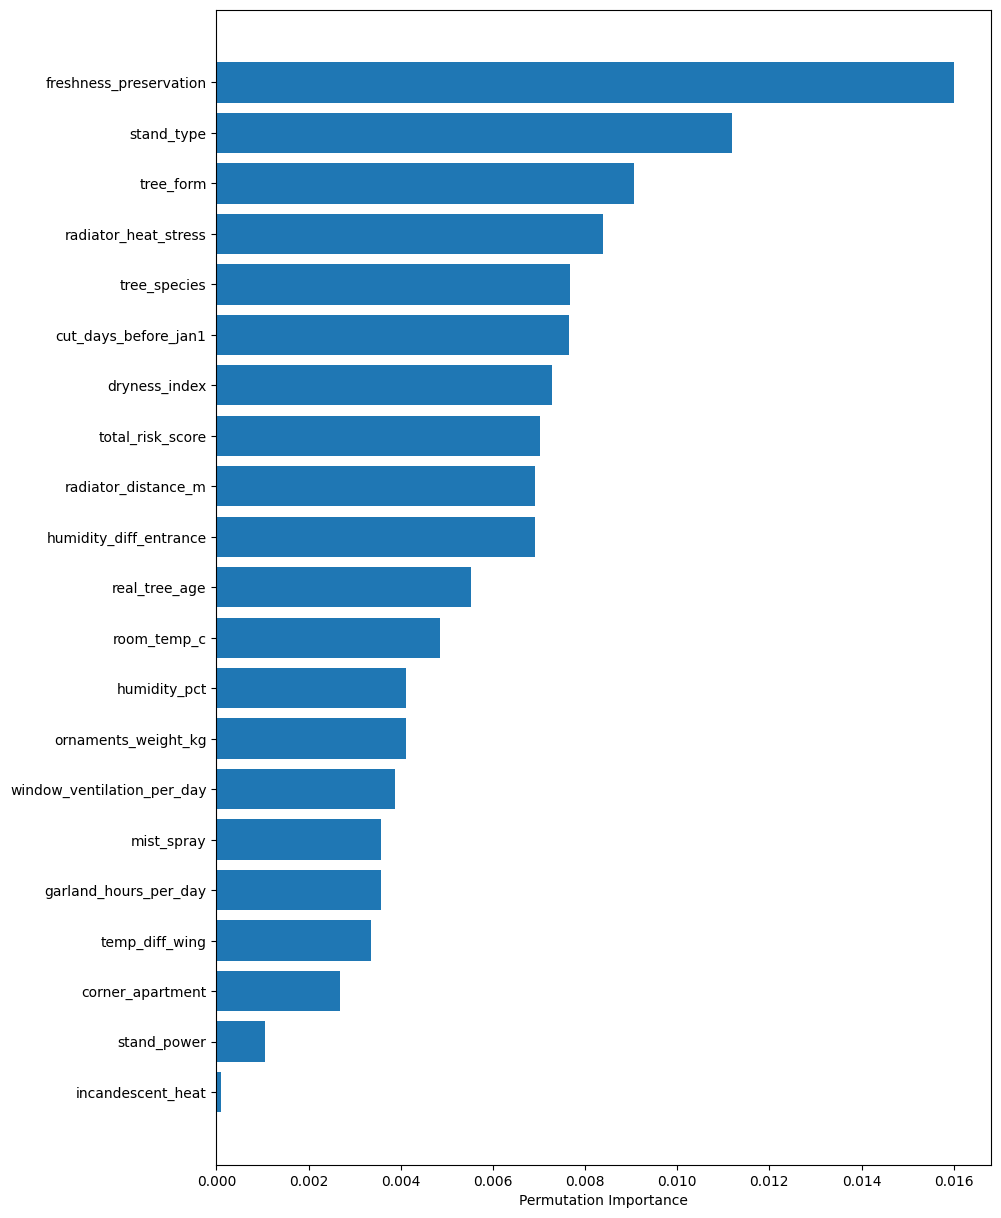

In [ ]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(model, X_valid, y_valid, n_repeats=10, random_state=42)

sorted_idx = perm_importance.importances_mean.argsort()

plt.figure(figsize=(10, 15))
plt.barh(np.array(features)[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

In [ ]:
# @title optuna
!pip install optuna
import optuna
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Настраиваем логирование Optuna, чтобы не спамило в консоль
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    # 1. Генерируем сетку гиперпараметров для этой попытки (trial)
    params = {
        'iterations': 2000,                        # Ставим с запасом, early_stopping обрежет
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'depth': trial.suggest_int('depth', 6, 10), # Глубина дерева (важный параметр!)
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10), # Регуляризация (против переобучения)
        'random_strength': trial.suggest_float('random_strength', 1e-9, 10, log=True), # Случайность при сплитах
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),

        # Фиксированные параметры
        'eval_metric': 'AUC',
        'random_seed': 42,
        'early_stopping_rounds': 50,
        'verbose': 100, # Молчим во время обучения
    }

    # 2. Стратегия кросс-валидации для оценки параметров
    # Для ускорения подбора можно поставить n_splits=3, но 5 надежнее
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    cv_scores = []

    # 3. Цикл обучения (аналогично твоему коду, но компактнее)
    for train_idx, valid_idx in skf.split(train_df, train_df[target]):
        X_train, X_valid = train_df.iloc[train_idx][features], train_df.iloc[valid_idx][features]
        y_train, y_valid = train_df.iloc[train_idx][target], train_df.iloc[valid_idx][target]

        model = CatBoostClassifier(**params)

        # Передаем категориальные фичи
        model.fit(
            X_train, y_train,
            eval_set=(X_valid, y_valid),
            cat_features=categorical_features,
            use_best_model=True
        )

        # Получаем скор лучшей итерации
        best_score = model.get_best_score()['validation']['AUC']
        cv_scores.append(best_score)

    # Возвращаем средний AUC по фолдам
    return np.mean(cv_scores)

# --- Запуск оптимизации ---
print("Начинаем подбор гиперпараметров...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30) # 30-50 итераций обычно достаточно для старта

print("-" * 50)
print(f"Лучший AUC: {study.best_value:.5f}")
print("Лучшие параметры:")
print(study.best_params)

# Сохраняем лучшие параметры в переменную
best_params = study.best_params
# Добавляем обязательные параметры, которые мы не перебирали
best_params.update({
    'iterations': 1500,
    'eval_metric': 'AUC',
    'random_seed': 42,
    'early_stopping_rounds': 80,
    'verbose': 100
})

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 13.1 MB/s eta 0:00:00
Начинаем подбор гиперпараметров...
0:	test: 0.6476462	best: 0.6476462 (0)	total: 135ms	remaining: 4m 29s
100:	test: 0.6693433	best: 0.6693433 (100)	total: 13.5s	remaining: 4m 14s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6699946053
bestIteration = 127

Shrink model to first 128 iterations.
0:	test: 0.6388346	best: 0.6388346 (0)	total: 245ms	remaining: 8m 10s
100:	test: 0.6738456	best: 0.6741497 (91)	total: 14.6s	remaining: 4m 34s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6743222979
bestIteration = 109

Shrink model to first 110 iterations.
0:	test: 0.6392695	best: 0.6392695 (0)	total: 143ms	remaining: 4m 45s
100:	test: 0.6678546	best: 0.6678810 (85)	total: 13.6s	remaining: 4m 15s
200:	test: 0.6699188	best: 0.6704907 (172)	total: 26.9s	remaining: 4m 1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.6704907053
bestIteration = 172

Shrin

In [ ]:
test = pd.read_csv('/content/test.csv')

In [ ]:
test_df, clip_vals = clip_by_quantile(
    test,
    clip_features
)

# test_df = test.copy()

test_df['stand_type_te'] = test_df['stand_type'].map(mean_survival)
test_df['form_plus_species'] = (
    test_df['tree_species'].map(type_of_tree)
    * test_df['tree_form'].map(tree_form_te)
)
test_df['dryness_index'] = test_df['room_temp_c'] / (test_df['humidity_pct'] + 1)

test_df['incandescent_heat'] = (
    test_df['garland_hours_per_day'] * (1 - test_df['led_garland'])
)

test_df['radiator_heat_stress'] = (
    test_df['room_temp_c'] / (test_df['radiator_distance_m'] + 0.1)
)

test_df['chaos_factor'] = (
    test_df['children_count']
    + test_df['cat_present']
    + test_df['ornaments_weight_kg']
)

window_map = {'old': 3, 'normal': 2, 'new': 1}

test_df['draft_score'] = (
    test_df['window_ventilation_per_day']
    * test_df['window_quality'].map(window_map)
)

test_df['water_per_cm'] = (
    test_df['waterings_per_week'] / (test_df['tree_height_cm'] + 1)
)
test_df['real_tree_age'] = (
    (test_df['cut_days_before_jan1'] + 18)
    * (1 - test_df['potted_tree'])
)

test_df['incandescent_heat'] = test_df['garland_hours_per_day'] * (1 - test_df['led_garland'])
test_df['total_risk_score'] = test_df.apply(calculate_risk_score, axis=1)

test_df = create_group_stats(test_df)

test_df['cat_interaction'] = test_df['cat_present'] * test_df['ornaments_weight_kg'] * (1 - test_df['potted_tree'])
test_df['garland_dryness_hit'] = test_df['incandescent_heat'] * test_df['dryness_index']
test_df['freshness_preservation'] = test_df['waterings_per_week'] / (test_df['cut_days_before_jan1'] + 1)
test_df['stand_power'] = test_df['stand_type'].map(stand_map)

test_df['hydro_efficiency'] = test_df['stand_power'] * test_df['waterings_per_week']

test_df = create_thermal_gradient_features(test_df)

In [ ]:
A = set(test_df.columns.tolist())
B = set(train_df.columns.tolist())
print(B-A)

{'survived_to_18jan'}


In [ ]:
test_df[categorical_features] = test_df[categorical_features].fillna("unknown")

test_preds_cumulative = np.zeros(len(test_df))

cat_params = {**best_params}

print(f"Начинаем обучение на {n_splits} фолдах...")

for fold, (train_idx, valid_idx) in enumerate(skf.split(train_df, train_df[target])):
    X_train = train_df.iloc[train_idx][features]
    y_train = train_df.iloc[train_idx][target]
    X_valid = train_df.iloc[valid_idx][features]
    y_valid = train_df.iloc[valid_idx][target]

    model = CatBoostClassifier(**cat_params, rsm=0.8, subsample=0.8)
    model.fit(
        X_train, y_train,
        eval_set=(X_valid, y_valid),
        cat_features=categorical_features,
        use_best_model=True
    )

    val_auc = model.get_best_score()['validation']['AUC']
    print(f"Fold {fold+1}: AUC = {val_auc:.4f}")

    test_preds_cumulative += model.predict_proba(test_df[features])[:, 1]

final_predictions = test_preds_cumulative / n_splits

submission = pd.DataFrame({
    'apartment_id': test_df['apartment_id'],
    'survived_to_18jan': final_predictions
})

submission.to_csv('veniamin_submission10.csv', index=False)
print("Файл veniamin_submission.csv успешно создан!")

print(submission.head())

Начинаем обучение на 5 фолдах...
0:	test: 0.6322195	best: 0.6322195 (0)	total: 51.3ms	remaining: 1m 16s
100:	test: 0.6693676	best: 0.6693676 (100)	total: 5.68s	remaining: 1m 18s
200:	test: 0.6730827	best: 0.6730827 (200)	total: 9.43s	remaining: 1m
300:	test: 0.6742748	best: 0.6742748 (300)	total: 11.3s	remaining: 45s
400:	test: 0.6749874	best: 0.6751252 (356)	total: 13.4s	remaining: 36.8s
500:	test: 0.6751523	best: 0.6753449 (422)	total: 16.4s	remaining: 32.7s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 0.6753449379
bestIteration = 422

Shrink model to first 423 iterations.
Fold 1: AUC = 0.6753
0:	test: 0.6266467	best: 0.6266467 (0)	total: 26.9ms	remaining: 40.3s
100:	test: 0.6723871	best: 0.6723871 (100)	total: 2.17s	remaining: 30s
200:	test: 0.6761960	best: 0.6761960 (200)	total: 4.26s	remaining: 27.5s
300:	test: 0.6766744	best: 0.6768644 (249)	total: 6.22s	remaining: 24.8s
400:	test: 0.6766793	best: 0.6769259 (370)	total: 9s	remaining: 24.7s
500:	test: 0.67624